In [79]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score


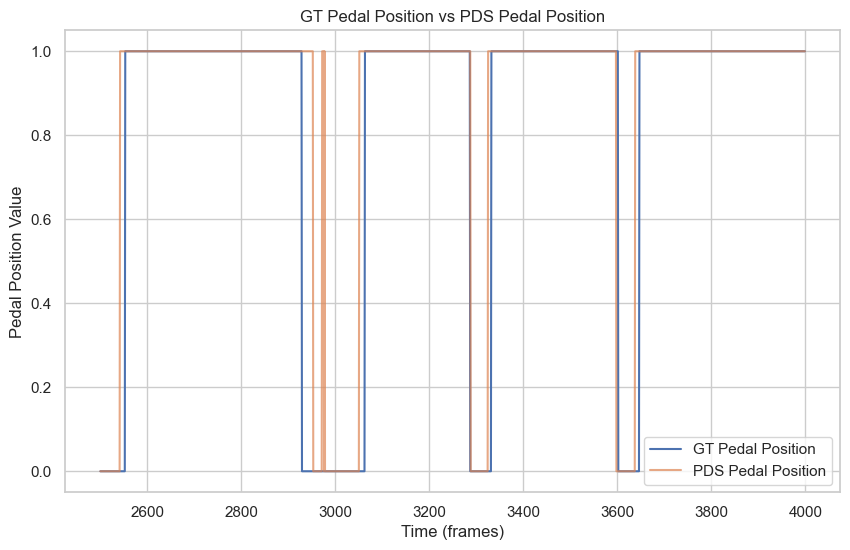

In [80]:

trials = ["t1","t2"]
base_path = "/standard/UVA-DSA/MIDAS/Organized/09-18-25/hamid"

complete_df = pd.DataFrame()
for trial in trials:
    csv_path = f"{base_path}/{trial}/synched_data/final_annotation_{trial}.csv"

    df = pd.read_csv(csv_path)

    complete_df = pd.concat([complete_df, df], ignore_index=True)

# drop all rows with NaN values
complete_df = complete_df.dropna()

gt_pedal_column_name =  "console_pedal"
pds_pedal_column_name = "Pedal 5 Pressesd"

# drop all rows with -1 in console_pedal
complete_df = complete_df[complete_df[gt_pedal_column_name] != -1]

# invert the "Pedal Position" column
complete_df[pds_pedal_column_name] = 1 - complete_df[pds_pedal_column_name]

window_start = 2500
window_end = 4000

# filter the DataFrame for the specified window
filtered_df = complete_df.iloc[window_start:window_end]

plt.figure(figsize=(10, 6))
plt.plot(filtered_df[gt_pedal_column_name], label='GT Pedal Position')
plt.xlabel('Time (frames)')
plt.ylabel('Pedal Position Value')

# compare console_pedal vs "Pedal Position" column
plt.plot(filtered_df[pds_pedal_column_name], label='PDS Pedal Position', alpha=0.7)
plt.legend()
plt.title('GT Pedal Position vs PDS Pedal Position')
plt.show()

## Compute F1, Precision, Recall and Accuracy for PDS pedal vs console

In [81]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, balanced_accuracy_score,
    cohen_kappa_score, matthews_corrcoef
)

# ---------- helpers ----------
def _align_by_xcorr(gt, pred, max_lag_frames=30):
    """Estimate a fixed lag via cross-correlation and shift pred to maximize agreement."""
    a = gt.astype(float) - gt.mean()
    b = pred.astype(float) - pred.mean()
    ac = np.correlate(a, b, mode='full')
    lags = np.arange(-len(a)+1, len(a))
    m = (lags >= -max_lag_frames) & (lags <= max_lag_frames)
    best_lag = int(lags[m][np.argmax(ac[m])])
    if best_lag > 0:
        pred_aligned = np.r_[np.zeros(best_lag, dtype=int), pred[:-best_lag]]
    elif best_lag < 0:
        pred_aligned = np.r_[pred[-best_lag:], np.zeros(-best_lag, dtype=int)]
    else:
        pred_aligned = pred
    return pred_aligned, best_lag

def _segments_from_binary(x):
    """Return [(start,end)] (inclusive) for contiguous 1-runs."""
    x = np.asarray(x, dtype=int)
    if len(x) == 0: return []
    starts = np.where((x[1:]==1) & (x[:-1]==0))[0] + 1
    ends   = np.where((x[1:]==0) & (x[:-1]==1))[0]
    if x[0]==1:  starts = np.r_[0, starts]
    if x[-1]==1: ends   = np.r_[ends, len(x)-1]
    return [(int(s), int(e)) for s, e in zip(starts, ends)]

def _safe_stats(values):
    if len(values) == 0:
        return dict(mean=np.nan, median=np.nan, std=np.nan)
    a = np.asarray(values, float)
    return dict(mean=float(a.mean()), median=float(np.median(a)), std=float(a.std(ddof=0)))

def _match_segments(gt_seg, pr_seg, onset_tol_frames=2, min_iou=0.5):
    """
    Greedy 1-1 matching by nearest onset. Returns:
      matches: list of dict for each GT segment (or None if no prediction)
      matched_pred_idx: set of pred indices matched with OK criteria
    A match is 'OK' if |onset_err| <= onset_tol_frames and IoU >= min_iou.
    """
    used = set()
    matches = []
    ok_pred = set()

    for gi, (gs, ge) in enumerate(gt_seg):
        if len(pr_seg) == 0:
            matches.append(None)
            continue

        # pick nearest pred by onset distance among unused ones
        cand = [(pi, ps, pe) for pi, (ps, pe) in enumerate(pr_seg) if pi not in used]
        if not cand:
            matches.append(None)
            continue
        pi, ps, pe = min(cand, key=lambda t: abs(t[1] - gs))

        onset_err = ps - gs
        overlap = max(0, min(ge, pe) - max(gs, ps) + 1)
        union = (ge - gs + 1) + (pe - ps + 1) - overlap
        iou = (overlap / union) if union > 0 else 0.0
        ok = (abs(onset_err) <= onset_tol_frames) and (iou >= min_iou)

        matches.append(dict(pred_idx=pi, onset_err=onset_err, offset_err=(pe - ge), iou=iou, ok=ok))
        used.add(pi)
        if ok:
            ok_pred.add(pi)

    return matches, ok_pred

# ---------- main evaluator ----------
def compute_pedal_metrics(
    gt_pedal, pds_pedal,
    fps=30.0,
    estimate_lag=True,
    max_lag_seconds=0.5,     # search window for fixed lag
    onset_tol_ms=50,         # tolerance for onset (segment-level)
    min_iou=0.5              # minimum temporal IoU for a segment to count
):
    gt = np.asarray(gt_pedal, dtype=int).flatten()
    pr = np.asarray(pds_pedal, dtype=int).flatten()
    assert gt.shape == pr.shape and gt.ndim == 1, "gt and pred must be same-length 1D arrays"

    # Optional fixed-lag alignment (applied to predictions)
    lag_frames = 0
    if estimate_lag:
        max_lag_frames = int(round(max_lag_seconds * fps))
        pr, lag_frames = _align_by_xcorr(gt, pr, max_lag_frames=max_lag_frames)

    # ---- frame-level metrics ----
    tn, fp, fn, tp = confusion_matrix(gt, pr, labels=[0, 1]).ravel()
    N = len(gt)
    accuracy = (tp + tn) / N if N > 0 else np.nan
    precision = precision_score(gt, pr, zero_division=0)
    recall = recall_score(gt, pr, zero_division=0)
    f1 = f1_score(gt, pr, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    bal_acc = balanced_accuracy_score(gt, pr)
    kappa = cohen_kappa_score(gt, pr)
    mcc = matthews_corrcoef(gt, pr) if (tp+tn+fp+fn) > 0 else np.nan

    # Temporal IoU over the active time (global)
    inter = np.logical_and(gt == 1, pr == 1).sum()
    union = np.logical_or(gt == 1, pr == 1).sum()
    temporal_iou = (inter / union) if union > 0 else (1.0 if inter == 0 else 0.0)

    # ---- segment / event metrics ----
    gt_seg = _segments_from_binary(gt)
    pr_seg = _segments_from_binary(pr)

    onset_tol_frames = int(round((onset_tol_ms / 1000.0) * fps))
    matches, ok_pred = _match_segments(gt_seg, pr_seg, onset_tol_frames=onset_tol_frames, min_iou=min_iou)

    # segment-level recall (tolerance)
    num_gt = len(gt_seg)
    ok_count = sum(1 for m in matches if (m is not None and m["ok"]))
    seg_recall = ok_count / num_gt if num_gt > 0 else (1.0 if len(pr_seg) == 0 else 0.0)

    # segment-level precision (tolerance)
    num_pr = len(pr_seg)
    seg_precision = len(ok_pred) / num_pr if num_pr > 0 else (1.0 if num_gt == 0 else 0.0)

    seg_f1 = (2 * seg_precision * seg_recall / (seg_precision + seg_recall)) if (seg_precision + seg_recall) > 0 else 0.0

    # onset/offset errors (frames)
    onset_errs = [m["onset_err"] for m in matches if m is not None]
    offset_errs = [m["offset_err"] for m in matches if m is not None]
    onset_stats_f = _safe_stats(onset_errs)
    offset_stats_f = _safe_stats(offset_errs)

    # convert to ms
    frame_to_ms = 1000.0 / fps if fps > 0 else np.nan
    onset_stats_ms = {k: (v * frame_to_ms if pd.notna(v) else np.nan) for k, v in onset_stats_f.items()}
    offset_stats_ms = {k: (v * frame_to_ms if pd.notna(v) else np.nan) for k, v in offset_stats_f.items()}

    # spurious activation rate (per minute): predicted segments not matched OK
    spurious = num_pr - len(ok_pred)
    duration_min = (N / fps) / 60.0 if fps > 0 else np.nan
    spurious_per_min = (spurious / duration_min) if duration_min and duration_min > 0 else np.nan

    # package results
    metrics = dict(
        # frame-level
        frames=N, tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn),
        accuracy=float(accuracy),
        precision=float(precision), recall=float(recall), f1=float(f1),
        specificity=float(specificity), balanced_accuracy=float(bal_acc),
        cohen_kappa=float(kappa), mcc=float(mcc),
        temporal_iou=float(temporal_iou),
        # alignment
        lag_frames=int(lag_frames),
        lag_ms=float(lag_frames * frame_to_ms) if fps > 0 else np.nan,
        # segments
        gt_segments=num_gt, pred_segments=num_pr,
        seg_precision=float(seg_precision), seg_recall=float(seg_recall), seg_f1=float(seg_f1),
        onset_tol_ms=float(onset_tol_ms), min_iou=float(min_iou),
        onset_err_frames=onset_stats_f, offset_err_frames=offset_stats_f,
        onset_err_ms=onset_stats_ms, offset_err_ms=offset_stats_ms,
        spurious_per_min=float(spurious_per_min)
    )
    return metrics

# ---------- your original wrapper (kept) ----------
def compute_metrics(gt_pedal, pds_pedal):
    """Keeps your original four metrics."""
    f1 = f1_score(gt_pedal, pds_pedal, zero_division=0)
    precision = precision_score(gt_pedal, pds_pedal, zero_division=0)
    recall = recall_score(gt_pedal, pds_pedal, zero_division=0)
    accuracy = accuracy_score(gt_pedal, pds_pedal)
    return f1, precision, recall, accuracy

# ---------- example usage ----------
f1, precision, recall, accuracy = compute_metrics(complete_df[gt_pedal_column_name], complete_df[pds_pedal_column_name])
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")

metrics = compute_pedal_metrics(
    complete_df[gt_pedal_column_name].values,
    complete_df[pds_pedal_column_name].values,
    fps=30.0,                # <-- set your true frame rate
    estimate_lag=True,       # set False if you already synchronized
    max_lag_seconds=0.5,     # search ±0.5 s
    onset_tol_ms=50,         # ±50 ms onset tolerance
    min_iou=0.5              # ≥50% overlap to count
)
print(pd.Series(metrics))

results_dir = "pedal_accuracy_results"
os.makedirs(results_dir, exist_ok=True)

# save metrics to CSV
metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(f"{results_dir}/pedal_accuracy_metrics.csv", index=False)

F1 Score: 0.8479
Precision: 0.7715
Recall: 0.9412
Accuracy: 0.7642
frames                                                           20603
tp                                                               13616
fp                                                                3937
tn                                                                2273
fn                                                                 777
accuracy                                                      0.771198
precision                                                     0.775708
recall                                                        0.946015
f1                                                            0.852438
specificity                                                   0.366023
balanced_accuracy                                             0.656019
cohen_kappa                                                   0.364809
mcc                                                           0.403184
temporal_i

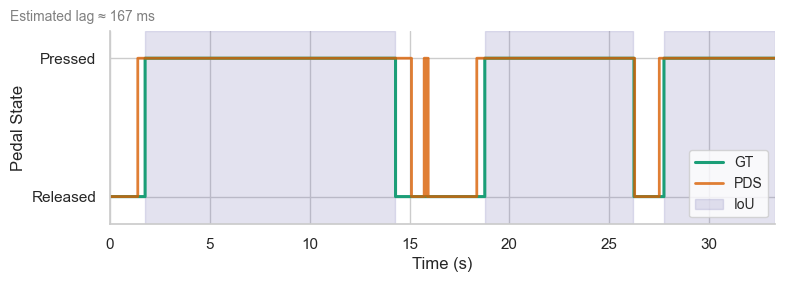

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Config ---
window_start = 2500
window_end   = 3500
fps = 30.0  # adjust to your actual frame rate

# --- Extract window ---
filtered_df = complete_df.iloc[window_start:window_end].copy()
frames = np.arange(window_start, window_end)
time_s = (frames - window_start) / fps  # convert to seconds for x-axis

gt = filtered_df[gt_pedal_column_name].to_numpy()
pds = filtered_df[pds_pedal_column_name].to_numpy()

# --- Figure styling ---
sns.reset_orig()
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 3))

# --- Plot signals as filled steps for clarity ---
plt.step(time_s, gt, where='post', linewidth=2.2, color='#1b9e77', label='GT')
plt.step(time_s, pds, where='post', linewidth=2.0, color='#d95f02', alpha=0.8, label='PDS')

# Optional shading for overlapping active regions
overlap = np.logical_and(gt == 1, pds == 1)
plt.fill_between(time_s, 0, 1,
                 where=overlap, color='#7570b3', alpha=0.2, transform=plt.gca().get_xaxis_transform(),
                 label='IoU')

# --- Axis & labels ---
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Pedal State', fontsize=12)
plt.yticks([0, 1], ['Released', 'Pressed'])
plt.ylim(-0.2, 1.2)
plt.xlim(time_s[0], time_s[-1])

# --- Legend & title ---
plt.legend(loc='lower right', frameon=True, fontsize=10)

# --- Annotate lag if known ---
lag_frames = 5
lag_ms = lag_frames * 1000 / fps
plt.text(-0.15, 1.05, f'Estimated lag ≈ {lag_ms:.0f} ms',
         transform=plt.gca().transAxes, fontsize=10, color='gray')

# --- Layout ---
sns.despine()
plt.tight_layout()
# save figure as pdf
plt.savefig(f"{results_dir}/pedal_accuracy_comparison.pdf", format='pdf', dpi=300)

plt.show()


